# Introduction to Machine Learning: Supervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 3: Classification Methods

---

In [1]:
# ## Setup (do not edit)
#
# This cell imports all necessary libraries for the assignment.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
)

# Set a random state for reproducibility
RANDOM_STATE = 42

## 1. Load and Describe the Data (10 points)

The dataset for this lab is the **Wisconsin Breast Cancer dataset**. The features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. The target column, `diagnosis`, indicates whether a tumor is **M** (malignant) or **B** (benign).

In [2]:
import pandas as pd

df = pd.read_csv("wisconsin_breast_cancer.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert "df" in locals(), "DataFrame 'df' not found."
assert df.shape[0] > 0, "DataFrame 'df' is empty."
assert "diagnosis" in df.columns, "The 'diagnosis' column is missing."
print("DataFrame loaded successfully!")
df.head()

DataFrame loaded successfully!


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 2. Prepare the Data (10 points)

Before training a model, the data needs to be preprocessed. This involves encoding the target variable to a numerical format, dropping unnecessary columns, and separating features from the target.

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert "X" in locals() and "y" in locals(), "X and/or y are not defined."
assert y.dtype == "int64" or y.dtype == "int32", "Target 'y' is not numeric."
assert X.shape[1] == 30, "Feature matrix 'X' should have 30 columns."
print("Data preparation successful!")

Data preparation successful!


## 3. Data Splitting and Scaling (10 points)

To evaluate the model's performance on unseen data, we must split the dataset into training and testing sets. We will also scale the features, which is crucial for distance-based and optimization-based algorithms like Logistic Regression and LDA.

In [6]:
# Grade Cell: Question 3
#
# Task: Split and scale the data.
#
# Instructions:
# 1. Split `X` and `y` into `X_train`, `X_test`, `y_train`, and `y_test` with a `test_size` of 0.2 and `random_state=RANDOM_STATE`.
# 2. Initialize a `StandardScaler` and fit it on `X_train`.
# 3. Transform both `X_train` and `X_test` using the fitted scaler, naming them `X_train_scaled` and `X_test_scaled`.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert "X_train_scaled" in locals(), "Scaled training data not found."
assert "X_test_scaled" in locals(), "Scaled test data not found."
assert X_train.shape[0] > 0 and X_test.shape[0] > 0, "Train/test sets are empty."
print("Data splitting and scaling successful!")

Data splitting and scaling successful!


## 4. Train a Basic Logistic Regression Model (10 points)

Now it's time to train our first classification model. You will use `LogisticRegression` from Scikit-learn to build a baseline model.

In [8]:
# Grade Cell: Question 4
#
# Task: Train a baseline logistic regression model.
#
# Instructions:
# 1. Initialize a `LogisticRegression` model, setting `random_state` to `RANDOM_STATE`.
# 2. Train the model using the scaled training data (`X_train_scaled`, `y_train`).
# 3. Store the trained model in a variable called `log_reg_baseline`.

# your code here
from sklearn.linear_model import LogisticRegression

log_reg_baseline = LogisticRegression(random_state=RANDOM_STATE)
log_reg_baseline.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert "log_reg_baseline" in locals(), "Baseline logistic regression model not found."
assert hasattr(log_reg_baseline, "coef_"), "Model does not appear to be trained."
print("Baseline model training successful!")

Baseline model training successful!


## 5. Make Predictions and Evaluate (10 points)

With a trained model, you can now make predictions and evaluate its performance using key classification metrics.

In [10]:
# Grade Cell: Question 5
#
# Task: Make predictions and calculate performance metrics.
#
# Instructions:
# 1. Use the baseline model to make predictions on the scaled test data. Store them in `y_pred_baseline`.
# 2. Calculate accuracy, precision, recall, and F1-score. Store them in `accuracy_baseline`, `precision_baseline`, `recall_baseline`, and `f1_baseline`.

# your code here
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_baseline = log_reg_baseline.predict(X_test_scaled)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)

accuracy_baseline, precision_baseline, recall_baseline, f1_baseline

(0.9736842105263158,
 0.9761904761904762,
 0.9534883720930233,
 0.9647058823529412)

In [11]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert "y_pred_baseline" in locals(), "Baseline predictions not found."
assert "accuracy_baseline" in locals(), "Baseline accuracy not calculated."
print(f"Baseline Accuracy: {accuracy_baseline:.4f}")
print(f"Baseline Precision: {precision_baseline:.4f}")
print(f"Baseline Recall: {recall_baseline:.4f}")
print(f"Baseline F1 Score: {f1_baseline:.4f}")

Baseline Accuracy: 0.9737
Baseline Precision: 0.9762
Baseline Recall: 0.9535
Baseline F1 Score: 0.9647


## 6. Compute and Visualize the Confusion Matrix (10 points)

The confusion matrix provides a detailed breakdown of correct and incorrect classifications, which is essential for understanding a model's performance beyond a single accuracy score.

**Note**: For autograding, only the computed `conf_matrix_baseline` variable will be checked, not the plot itself.

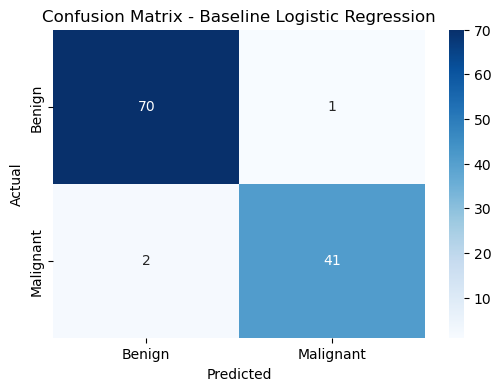

In [19]:
# Grade Cell: Question 6
#
# Task: Compute and visualize the confusion matrix for the baseline model.
#
# Instructions:
# 1. Compute the confusion matrix using `y_test` and `y_pred_baseline`. Store it in `conf_matrix_baseline`.
# 2. Use `seaborn.heatmap` to visualize the confusion matrix.

# your code here
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()

In [20]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert "conf_matrix_baseline" in locals(), "Baseline confusion matrix not found."
assert conf_matrix_baseline.shape == (
    2,
    2,
), "Confusion matrix has incorrect dimensions."
print("Baseline confusion matrix computed successfully.")

Baseline confusion matrix computed successfully.


## 7. Plot ROC Curve and Calculate AUC (10 points)

The ROC curve illustrates the diagnostic ability of a classifier as its discrimination threshold is varied. The Area Under the Curve (AUC) provides an aggregate measure of performance across all thresholds.

**Note**: For autograding, only the computed `roc_auc_baseline` variable will be checked, not the plot itself.

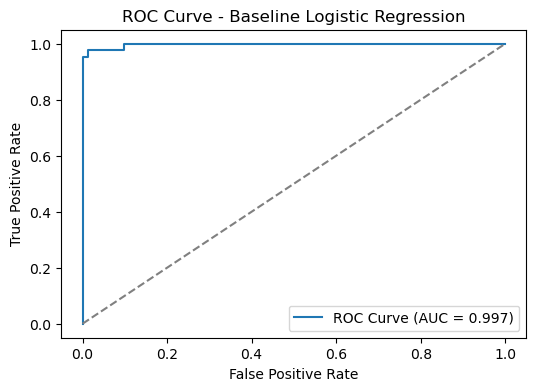

In [21]:
# Grade Cell: Question 7
#
# Task: Generate the ROC curve for the baseline model.
#
# Instructions:
# 1. Get the prediction probabilities for the positive class.
# 2. Compute the false positive rate (`fpr`), true positive rate (`tpr`), and thresholds.
# 3. Calculate the Area Under the ROC Curve (`roc_auc_baseline`).
# 4. Plot the ROC curve.

# your code here
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_baseline = log_reg_baseline.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_baseline)

roc_auc_baseline = float(roc_auc_score(y_test, y_prob_baseline))

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_baseline:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Logistic Regression')
plt.legend()
plt.show()

In [22]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert "roc_auc_baseline" in locals(), "ROC AUC for baseline model not calculated."
assert isinstance(roc_auc_baseline, (float, np.floating)), "ROC AUC must be a float"
assert 0.0 <= roc_auc_baseline <= 1.0, "ROC AUC must be between 0 and 1"
assert roc_auc_baseline > 0.5, "ROC AUC should be better than random (>0.5)"
print(f"Baseline Model AUC: {roc_auc_baseline:.4f}")

Baseline Model AUC: 0.9974


## 8. Implement L2 Regularization (10 points)

Regularization is a technique to prevent overfitting by penalizing large model coefficients. You will now train a logistic regression model with L2 regularization.

In [23]:
# Grade Cell: Question 8
#
# Task: Train a regularized logistic regression model.
#
# Instructions:
# 1. Initialize a `LogisticRegression` model with `penalty='l2'`, `C=0.1`, and `random_state=RANDOM_STATE`.
# 2. Train the model on the scaled training data.
# 3. Store the trained model in `log_reg_l2`.
# 4. Make predictions on the scaled test data and calculate the accuracy, storing it in `accuracy_l2`.

# your code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg_l2 = LogisticRegression(penalty='l2', C=0.1, random_state=RANDOM_STATE)
log_reg_l2.fit(X_train_scaled, y_train)
y_pred_l2 = log_reg_l2.predict(X_test_scaled)
accuracy_l2 = accuracy_score(y_test, y_pred_l2)

In [24]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert "log_reg_l2" in locals(), "L2 regularized model not found."
assert hasattr(log_reg_l2, "coef_"), "L2 model does not appear to be trained."
assert "accuracy_l2" in locals(), "Accuracy for L2 model not calculated."
print(f"L2 Regularized Model Accuracy: {accuracy_l2:.4f}")

L2 Regularized Model Accuracy: 0.9825


## 9. Compare Regularized vs. Unregularized Model (10 points)

Let's compare the coefficients of the baseline and regularized models to see the effect of regularization. Regularization should "shrink" the coefficients toward zero.

In [25]:
# Grade Cell: Question 9
#
# Task: Compare the magnitudes of the model coefficients.
#
# Instructions:
# 1. Calculate the average absolute value of the coefficients for the baseline model (`log_reg_baseline`) and store it in `avg_coef_baseline`.
# 2. Calculate the average absolute value of the coefficients for the L2 regularized model (`log_reg_l2`) and store it in `avg_coef_l2`.

# your code here
import numpy as np

avg_coef_baseline = np.mean(np.abs(log_reg_baseline.coef_))
avg_coef_l2 = np.mean(np.abs(log_reg_l2.coef_))

In [26]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert "avg_coef_baseline" in locals(), "Average baseline coefficient not found."
assert "avg_coef_l2" in locals(), "Average L2 coefficient not found."
print(f"Average Baseline Coefficient Magnitude: {avg_coef_baseline:.4f}")
print(f"Average L2 Regularized Coefficient Magnitude: {avg_coef_l2:.4f}")
assert (
    avg_coef_l2 < avg_coef_baseline
), "L2 coefficients should be smaller than baseline."
print(
    "Coefficient comparison successful. L2 regularization shrinks coefficients as expected."
)

Average Baseline Coefficient Magnitude: 0.5797
Average L2 Regularized Coefficient Magnitude: 0.2915
Coefficient comparison successful. L2 regularization shrinks coefficients as expected.


## 10. Train a Linear Discriminant Analysis (LDA) Model (10 points)

As an alternative approach, let's train a Linear Discriminant Analysis (LDA) model and compare its performance.

In [27]:
# Grade Cell: Question 10
#
# Task: Train an LDA model and evaluate its accuracy.
#
# Instructions:
# 1. Initialize a `LinearDiscriminantAnalysis` model.
# 2. Train the model on the scaled training data.
# 3. Make predictions on the scaled test data.
# 4. Calculate the accuracy and store it in `accuracy_lda`.

# your code here
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)
y_pred_lda = lda_model.predict(X_test_scaled)
accuracy_lda = accuracy_score(y_test, y_pred_lda)

In [28]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert "accuracy_lda" in locals(), "LDA accuracy not found."
assert isinstance(accuracy_lda, (float, np.floating)), "Accuracy must be a float"
assert 0.0 <= accuracy_lda <= 1.0, "Accuracy must be between 0 and 1"
assert accuracy_lda > 0.5, "Accuracy should be better than random guessing"
print(f"LDA Model Accuracy: {accuracy_lda:.4f}")
print(f"Baseline Logistic Regression Accuracy: {accuracy_baseline:.4f}")

LDA Model Accuracy: 0.9561
Baseline Logistic Regression Accuracy: 0.9737


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
